# Yelp Metric Comparisons

Load the saved metric rows and compare models across threshold choices.

In [33]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120


In [34]:
DRIVE_METRICS_PATH = Path("/content/drive/MyDrive/yelp/yelp_metrics.csv")
LOCAL_METRICS_PATH = Path("script/yelp/yelp_metrics.csv") if Path("script/yelp").exists() else Path("yelp_metrics.csv")
DRIVE_MCMC_METRICS_PATH = Path("/content/drive/MyDrive/yelp/yelp_mcmc_metrics.csv")
LOCAL_MCMC_METRICS_PATH = Path("script/yelp/yelp_mcmc_metrics.csv") if Path("script/yelp").exists() else Path("yelp_mcmc_metrics.csv")

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

METRICS_PATH = DRIVE_METRICS_PATH if DRIVE_METRICS_PATH.exists() else LOCAL_METRICS_PATH
if not METRICS_PATH.exists():
    raise FileNotFoundError(f"Could not find metrics CSV at {DRIVE_METRICS_PATH} or {LOCAL_METRICS_PATH}")

MCMC_METRICS_PATH = DRIVE_MCMC_METRICS_PATH if DRIVE_MCMC_METRICS_PATH.exists() else LOCAL_MCMC_METRICS_PATH
if not MCMC_METRICS_PATH.exists():
    raise FileNotFoundError(f"Could not find MCMC metrics CSV at {DRIVE_MCMC_METRICS_PATH} or {LOCAL_MCMC_METRICS_PATH}")

metrics = pd.read_csv(METRICS_PATH)
mcmc_metrics = pd.read_csv(MCMC_METRICS_PATH)
print(f"Loaded {len(metrics):,} rows from {METRICS_PATH}")
print(f"Loaded {len(mcmc_metrics):,} MCMC rows from {MCMC_METRICS_PATH}")
metrics.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 72 rows from /content/drive/MyDrive/yelp/yelp_metrics.csv
Loaded 18 MCMC rows from /content/drive/MyDrive/yelp/yelp_mcmc_metrics.csv


,rowname,threhold_type,threshold_value,f_1,balanced_accuracy,roc-aoc,precision_pos,recall_pos
0,gm_weighted_linear,0.5,0.500,0.393500,0.625063,0.869794,0.801418,0.260769
1,gm_weighted_linear,best_balanced_accuracy,0.143,0.498237,0.787634,0.869794,0.358714,0.815385
2,gm_weighted_linear,best_f1,0.254,0.556217,0.757171,0.869794,0.510611,0.610769
3,gm_weighted_nn,0.5,0.500,0.644244,0.753239,0.929763,0.838471,0.523077
4,gm_weighted_nn,best_balanced_accuracy,0.137,0.602121,0.845308,0.929763,0.465713,0.851538


In [35]:
rename_map = {
    "roc-aoc": "roc_auc",
    "f_1": "f1",
    "f1_pos": "f1",
    "threhold_type": "threshold_type",
}

required = [
    "rowname",
    "threshold_type",
    "threshold_value",
    "f1",
    "balanced_accuracy",
    "roc_auc",
    "precision_pos",
    "recall_pos",
]


def is_gm_weighted_rowname(value):
    return "gm_weighted" in str(value)


def presentation_rowname(value):
    value = str(value)
    value = value[2:] if value.startswith("S_") else value
    return value.replace("hm_weighted", "weighted")


def standardize_for_plots(frame, source):
    out = frame.rename(columns=rename_map).copy()
    missing = [column for column in required if column not in out.columns]
    if missing:
        raise ValueError(f"{source} metrics missing columns: {missing}")

    for column in required[2:]:
        out[column] = pd.to_numeric(out[column], errors="coerce")

    out = out.dropna(subset=["rowname", "threshold_type", "f1", "balanced_accuracy", "roc_auc"])
    out = out[~out["rowname"].map(is_gm_weighted_rowname)].copy()
    out["model_label"] = out["rowname"].map(presentation_rowname)
    out["metric_source"] = source
    out = out[required + ["model_label", "metric_source"]]
    out = out.drop_duplicates(subset=["model_label", "threshold_type"], keep="last")
    return out


base_plot_df = standardize_for_plots(metrics, "without_mcmc")
mcmc_plot_df = standardize_for_plots(mcmc_metrics, "with_mcmc")

plot_df = pd.concat([base_plot_df, mcmc_plot_df], ignore_index=True)
plot_df["source_priority"] = plot_df["metric_source"].map({"without_mcmc": 0, "with_mcmc": 1})
plot_df = (
    plot_df.sort_values(["model_label", "threshold_type", "source_priority"])
    .drop_duplicates(subset=["model_label", "threshold_type"], keep="last")
    .drop(columns="source_priority")
)

threshold_order = ["0.5", "best_balanced_accuracy", "best_f1"]
plot_df["threshold_type"] = pd.Categorical(plot_df["threshold_type"], categories=threshold_order, ordered=True)
plot_df = plot_df.sort_values(["model_label", "threshold_type"])

plot_df.head()

,rowname,threshold_type,threshold_value,f1,balanced_accuracy,roc_auc,precision_pos,recall_pos,model_label,metric_source
12,Class_prior,0.5,0.500,0.000000,0.500000,0.500000,0.000000,0.000000,Class_prior,without_mcmc
13,Class_prior,best_balanced_accuracy,0.000,0.253658,0.500000,0.500000,0.145251,1.000000,Class_prior,without_mcmc
14,Class_prior,best_f1,0.000,0.253658,0.500000,0.500000,0.145251,1.000000,Class_prior,without_mcmc
24,Feature_graph_stat_logistic_regression,0.5,0.500,0.551943,0.819295,0.905941,0.409652,0.845693,Feature_graph_stat_logistic_regression,without_mcmc
25,Feature_graph_stat_logistic_regression,best_balanced_accuracy,0.599,0.582250,0.811111,0.905941,0.467544,0.771536,Feature_graph_stat_logistic_regression,without_mcmc


In [36]:
best_f1_df = plot_df[plot_df["threshold_type"].eq("best_f1")].sort_values("f1", ascending=False)
best_balacc_df = plot_df[plot_df["threshold_type"].eq("best_balanced_accuracy")].sort_values("balanced_accuracy", ascending=False)

metric_display_columns = [
    "model_label",
    "metric_source",
    "threshold_value",
    "f1",
    "balanced_accuracy",
    "roc_auc",
    "precision_pos",
    "recall_pos",
]
display(best_f1_df[metric_display_columns].head(20).rename(columns={"model_label": "rowname"}))
display(best_balacc_df[metric_display_columns].head(20).rename(columns={"model_label": "rowname"}))

plot_titles = {
    "best_f1_bar": "Top Models by F1",
    "best_balanced_accuracy_bar": "Top Models by Balanced Accuracy",
    "best_f1_metric_heatmap": "Best F1 Threshold: Metric Heatmap",
    "precision_recall_thresholds": "Precision vs Recall Across Thresholds",
}

,rowname,metric_source,threshold_value,f1,balanced_accuracy,roc_auc,precision_pos,recall_pos
67,weighted_nn,with_mcmc,0.13900,0.730694,0.838251,0.946936,0.745004,0.716923
41,Relation_GCN_MLP_skip,without_mcmc,0.73200,0.699522,0.828621,0.938871,0.687139,0.712360
70,weighted_linear,with_mcmc,0.02600,0.665684,0.814996,0.924450,0.639066,0.694615
73,unweigh_neural,with_mcmc,0.08900,0.652872,0.814670,0.912440,0.608782,0.703846
50,Relation_GAT_MLP_skip,without_mcmc,0.76800,0.610568,0.764131,0.893516,0.639344,0.584270
53,LR_graph_feat,without_mcmc,0.88200,0.602368,0.787900,0.916420,0.550254,0.665385
65,LR_graph_logit_plus_EB_plus_graph_laplacian,without_mcmc,0.71900,0.602166,0.787126,0.916429,0.551504,0.663077
62,LR_graph_logit_plus_graph_laplacian,without_mcmc,0.71900,0.602166,0.787126,0.916420,0.551504,0.663077
59,LR_graph_logit_plus_EB,without_mcmc,0.72000,0.602166,0.787126,0.916429,0.551504,0.663077
56,LR_graph_logit_only,without_mcmc,0.72000,0.602166,0.787126,0.916420,0.551504,0.663077


,rowname,metric_source,threshold_value,f1,balanced_accuracy,roc_auc,precision_pos,recall_pos
68,weighted_nn,with_mcmc,0.046000,0.658329,0.878228,0.946936,0.522092,0.890769
40,Relation_GCN_MLP_skip,without_mcmc,0.447000,0.649490,0.862760,0.938871,0.522076,0.859176
71,weighted_linear,with_mcmc,0.007000,0.607048,0.854376,0.924450,0.464841,0.874615
58,LR_graph_logit_plus_EB,without_mcmc,0.502000,0.563352,0.835745,0.916429,0.415660,0.873846
55,LR_graph_logit_only,without_mcmc,0.502000,0.563352,0.835745,0.916420,0.415660,0.873846
61,LR_graph_logit_plus_graph_laplacian,without_mcmc,0.501000,0.563352,0.835745,0.916420,0.415660,0.873846
64,LR_graph_logit_plus_EB_plus_graph_laplacian,without_mcmc,0.501000,0.563352,0.835745,0.916429,0.415660,0.873846
52,LR_graph_feat,without_mcmc,-0.042245,0.563213,0.835681,0.916420,0.415508,0.873846
74,unweigh_neural,with_mcmc,0.041000,0.600747,0.830078,0.912440,0.479578,0.803846
77,unweigh_linear,with_mcmc,0.005000,0.544480,0.822798,0.897760,0.398502,0.859231


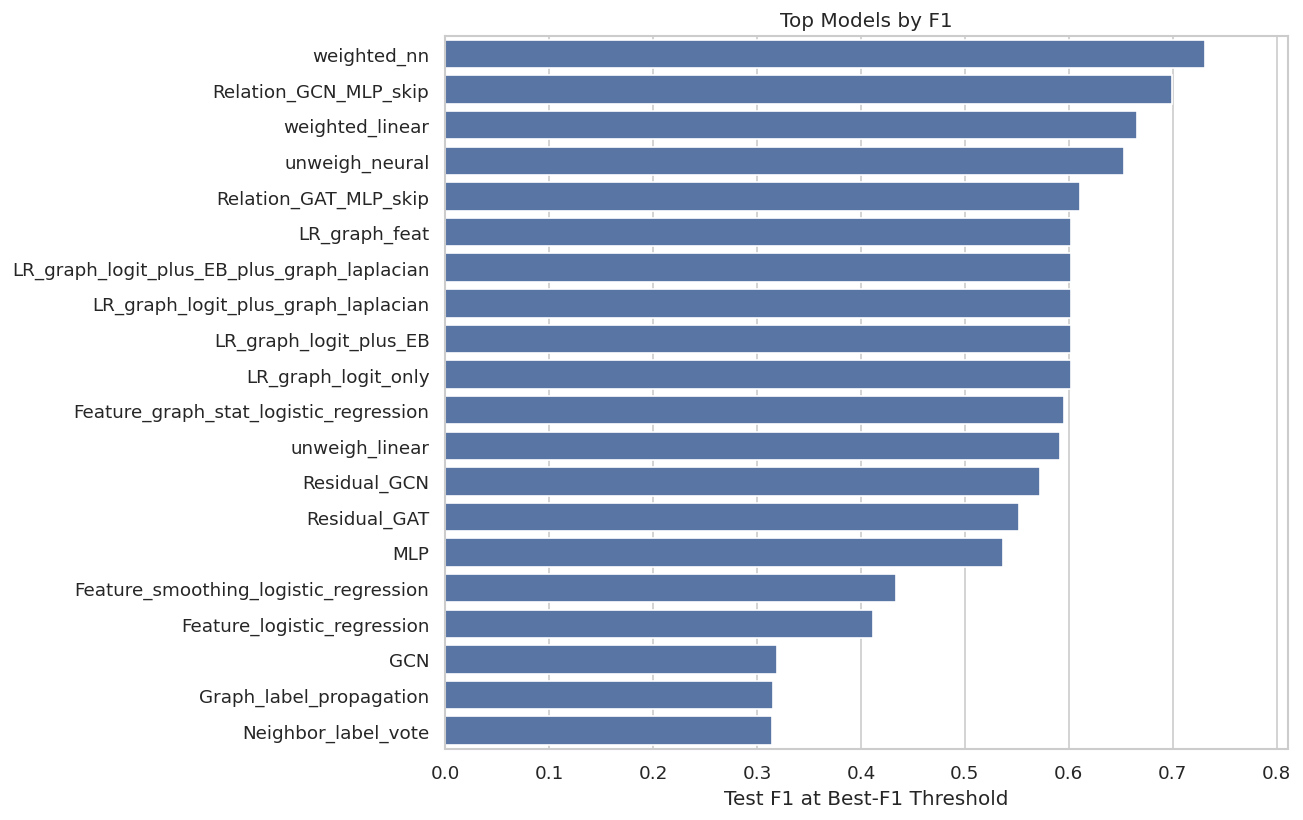

In [37]:
top_f1_df = best_f1_df.head(20).copy()
top_f1_names = top_f1_df["model_label"].tolist()

fig, ax = plt.subplots(figsize=(11, max(5, 0.35 * len(top_f1_names))))
sns.barplot(
    data=top_f1_df,
    y="model_label",
    x="f1",
    order=top_f1_names,
    color=sns.color_palette()[0],
    ax=ax,
)
ax.set_title(plot_titles["best_f1_bar"])
ax.set_xlabel("Test F1 at Best-F1 Threshold")
ax.set_ylabel("")
ax.set_xlim(0, min(1, max(0.05, top_f1_df["f1"].max() + 0.08)))
plt.tight_layout()
plt.show()

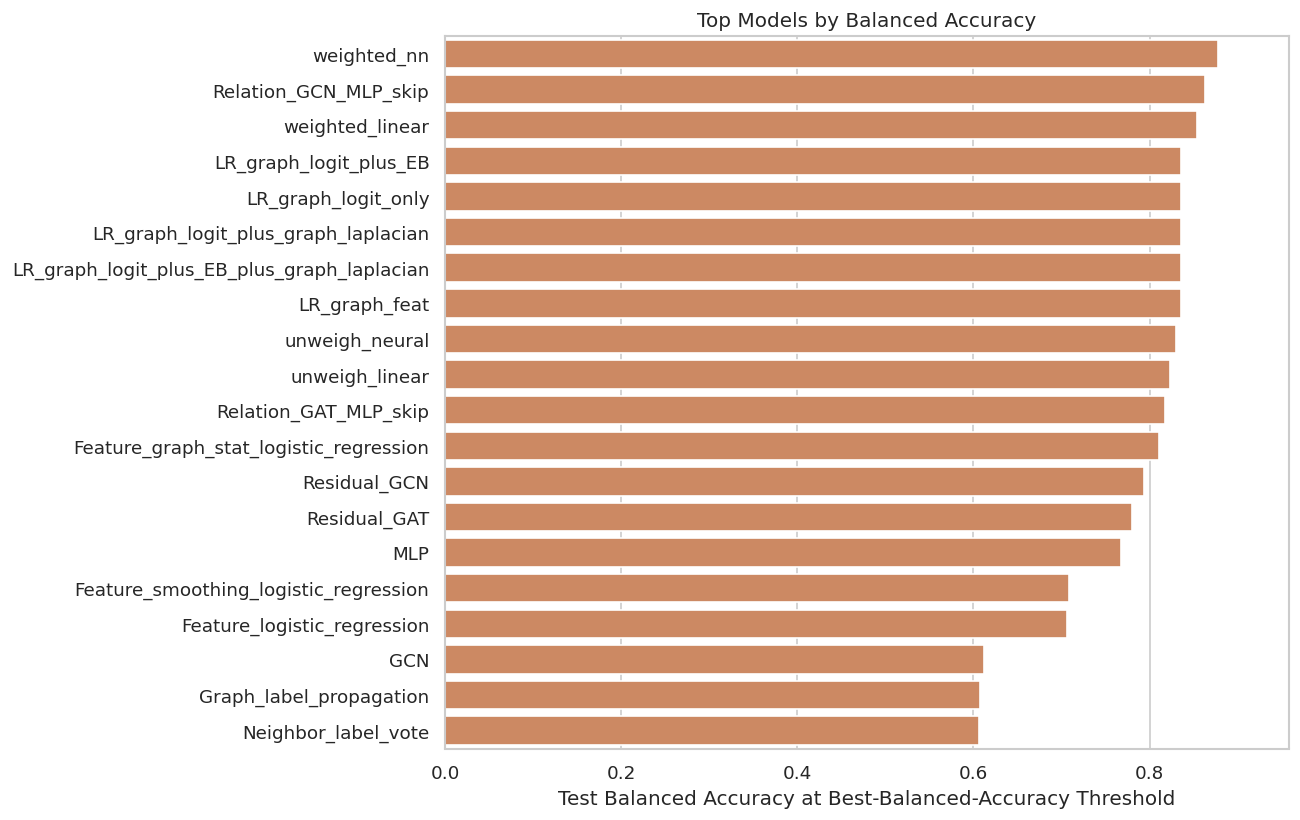

In [38]:
top_balacc_df = best_balacc_df.head(20).copy()
top_balacc_names = top_balacc_df["model_label"].tolist()

fig, ax = plt.subplots(figsize=(11, max(5, 0.35 * len(top_balacc_names))))
sns.barplot(
    data=top_balacc_df,
    y="model_label",
    x="balanced_accuracy",
    order=top_balacc_names,
    color=sns.color_palette()[1],
    ax=ax,
)
ax.set_title(plot_titles["best_balanced_accuracy_bar"])
ax.set_xlabel("Test Balanced Accuracy at Best-Balanced-Accuracy Threshold")
ax.set_ylabel("")
ax.set_xlim(0, min(1, max(0.05, top_balacc_df["balanced_accuracy"].max() + 0.08)))
plt.tight_layout()
plt.show()

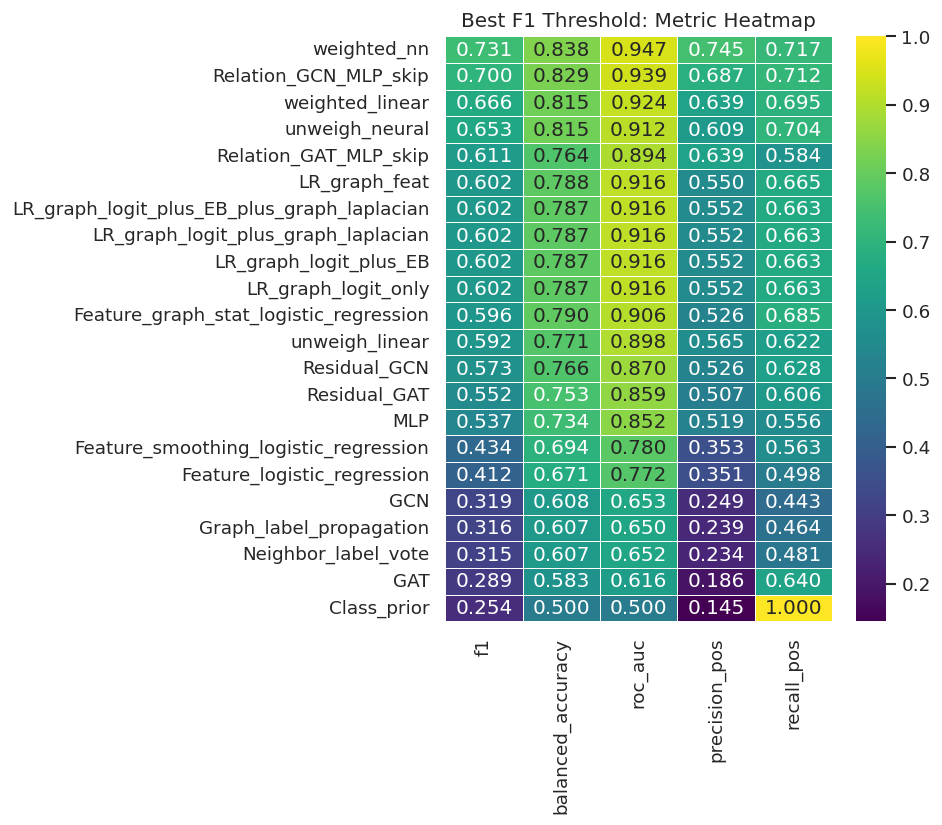

In [39]:
heat_df = best_f1_df.head(30).set_index("model_label")[[
    "f1",
    "balanced_accuracy",
    "roc_auc",
    "precision_pos",
    "recall_pos",
]]

fig, ax = plt.subplots(figsize=(8, max(5, 0.32 * len(heat_df))))
sns.heatmap(heat_df, annot=True, fmt=".3f", cmap="viridis", linewidths=0.4, ax=ax)
ax.set_title(plot_titles["best_f1_metric_heatmap"])
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

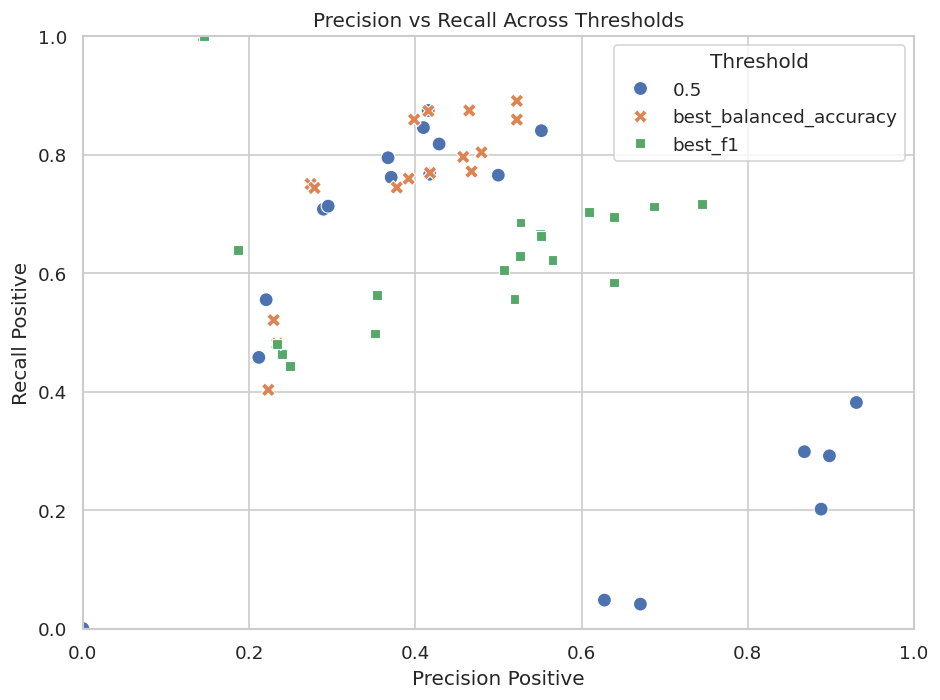

In [40]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="precision_pos",
    y="recall_pos",
    hue="threshold_type",
    style="threshold_type",
    hue_order=threshold_order,
    ax=ax,
    s=70,
)
ax.set_title(plot_titles["precision_recall_thresholds"])
ax.set_xlabel("Precision Positive")
ax.set_ylabel("Recall Positive")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(title="Threshold")
plt.tight_layout()
plt.show()


## Compare Non-MCMC vs MCMC Metrics

This section keeps the original comparisons above intact, then compares `yelp_metrics.csv` against `yelp_mcmc_metrics.csv`. It uses an inner join, so only model/threshold pairs present in both files are compared.


In [41]:
if "mcmc_metrics" not in globals():
    DRIVE_MCMC_METRICS_PATH = Path("/content/drive/MyDrive/yelp/yelp_mcmc_metrics.csv")
    LOCAL_MCMC_METRICS_PATH = Path("script/yelp/yelp_mcmc_metrics.csv") if Path("script/yelp").exists() else Path("yelp_mcmc_metrics.csv")
    MCMC_METRICS_PATH = DRIVE_MCMC_METRICS_PATH if DRIVE_MCMC_METRICS_PATH.exists() else LOCAL_MCMC_METRICS_PATH
    if not MCMC_METRICS_PATH.exists():
        raise FileNotFoundError(f"Could not find MCMC metrics CSV at {DRIVE_MCMC_METRICS_PATH} or {LOCAL_MCMC_METRICS_PATH}")
    mcmc_metrics = pd.read_csv(MCMC_METRICS_PATH)
    print(f"Loaded {len(mcmc_metrics):,} MCMC rows from {MCMC_METRICS_PATH}")
else:
    print(f"Using {len(mcmc_metrics):,} MCMC rows loaded above from {MCMC_METRICS_PATH}")

mcmc_metrics.head()

Using 18 MCMC rows loaded above from /content/drive/MyDrive/yelp/yelp_mcmc_metrics.csv


,rowname,threshold_type,threshold_value,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,roc_auc,average_precision,tn,fp,fn,tp
0,S_hm_weighted_nn,0.5,0.500,9192,0.141427,0.908507,0.688425,0.930582,0.381538,0.541189,0.946936,0.811997,7855,37,804,496
1,S_hm_weighted_nn,best_f1,0.139,9192,0.141427,0.925261,0.838251,0.745004,0.716923,0.730694,0.946936,0.811997,7573,319,368,932
2,S_hm_weighted_nn,best_balanced_accuracy,0.046,9192,0.141427,0.869234,0.878228,0.522092,0.890769,0.658329,0.946936,0.811997,6832,1060,142,1158
3,S_hm_weighted_linear,0.5,0.500,9192,0.141427,0.895126,0.643045,0.898104,0.291538,0.440186,0.924450,0.728971,7849,43,921,379
4,S_hm_weighted_linear,best_f1,0.026,9192,0.141427,0.901327,0.814996,0.639066,0.694615,0.665684,0.924450,0.728971,7382,510,397,903


In [42]:
def normalize_rowname(value):
    return presentation_rowname(value)


def standardize_metric_frame(frame, source):
    out = frame.rename(columns={
        "threhold_type": "threshold_type",
        "f_1": "f1_pos",
        "roc-aoc": "roc_auc",
    }).copy()

    out["source"] = source
    out = out[~out["rowname"].map(is_gm_weighted_rowname)].copy()
    out["rowname"] = out["rowname"].map(normalize_rowname)

    required = [
        "rowname",
        "threshold_type",
        "threshold_value",
        "f1_pos",
        "balanced_accuracy",
        "roc_auc",
        "precision_pos",
        "recall_pos",
    ]
    missing = [column for column in required if column not in out.columns]
    if missing:
        raise ValueError(f"{source} metrics missing columns: {missing}")

    for column in required[2:]:
        out[column] = pd.to_numeric(out[column], errors="coerce")

    out = out[required + ["source"]]
    out = out.dropna(subset=["rowname", "threshold_type", "f1_pos", "balanced_accuracy", "roc_auc"])
    out = out.drop_duplicates(subset=["rowname", "threshold_type"], keep="last")
    return out


without_mcmc = standardize_metric_frame(metrics, "without_mcmc")
with_mcmc = standardize_metric_frame(mcmc_metrics, "with_mcmc")

comparison = without_mcmc.merge(
    with_mcmc,
    on=["rowname", "threshold_type"],
    how="inner",
    suffixes=("_without_mcmc", "_with_mcmc"),
)

metric_names = ["threshold_value", "f1_pos", "balanced_accuracy", "roc_auc", "precision_pos", "recall_pos"]
for metric in metric_names:
    comparison[f"delta_{metric}"] = comparison[f"{metric}_with_mcmc"] - comparison[f"{metric}_without_mcmc"]

comparison = comparison.sort_values(["rowname", "threshold_type"])
print(f"Compared {len(comparison):,} rows present in both files.")
comparison[[
    "rowname",
    "threshold_type",
    "f1_pos_without_mcmc",
    "f1_pos_with_mcmc",
    "delta_f1_pos",
    "balanced_accuracy_without_mcmc",
    "balanced_accuracy_with_mcmc",
    "delta_balanced_accuracy",
    "roc_auc_without_mcmc",
    "roc_auc_with_mcmc",
    "delta_roc_auc",
]]

Compared 12 rows present in both files.


,rowname,threshold_type,f1_pos_without_mcmc,f1_pos_with_mcmc,delta_f1_pos,balanced_accuracy_without_mcmc,balanced_accuracy_with_mcmc,delta_balanced_accuracy,roc_auc_without_mcmc,roc_auc_with_mcmc,delta_roc_auc
6,unweigh_linear,0.5,0.551758,0.328527,-0.223231,0.705714,0.598679,-0.107035,0.909424,0.897760,-0.011664
7,unweigh_linear,best_balanced_accuracy,0.546563,0.544480,-0.002083,0.824654,0.822798,-0.001855,0.909424,0.897760,-0.011664
8,unweigh_linear,best_f1,0.596071,0.591941,-0.004129,0.793040,0.771362,-0.021677,0.909424,0.897760,-0.011664
9,unweigh_neural,0.5,0.622704,0.444190,-0.178514,0.743967,0.645493,-0.098474,0.920550,0.912440,-0.008110
10,unweigh_neural,best_balanced_accuracy,0.602072,0.600747,-0.001325,0.837689,0.830078,-0.007610,0.920550,0.912440,-0.008110
11,unweigh_neural,best_f1,0.666403,0.652872,-0.013531,0.799712,0.814670,0.014958,0.920550,0.912440,-0.008110
0,weighted_linear,0.5,0.613309,0.440186,-0.173123,0.741424,0.643045,-0.098379,0.930245,0.924450,-0.005795
1,weighted_linear,best_balanced_accuracy,0.628588,0.607048,-0.021541,0.846739,0.854376,0.007636,0.930245,0.924450,-0.005795
2,weighted_linear,best_f1,0.646915,0.665684,0.018768,0.816312,0.814996,-0.001316,0.930245,0.924450,-0.005795
3,weighted_nn,0.5,0.671034,0.541189,-0.129845,0.768167,0.688425,-0.079742,0.940625,0.946936,0.006311


In [43]:
display(
    comparison.sort_values("delta_f1_pos", ascending=False)[[
        "rowname",
        "threshold_type",
        "threshold_value_without_mcmc",
        "threshold_value_with_mcmc",
        "f1_pos_without_mcmc",
        "f1_pos_with_mcmc",
        "delta_f1_pos",
        "precision_pos_without_mcmc",
        "precision_pos_with_mcmc",
        "recall_pos_without_mcmc",
        "recall_pos_with_mcmc",
    ]]
)

display(
    comparison.sort_values("delta_balanced_accuracy", ascending=False)[[
        "rowname",
        "threshold_type",
        "balanced_accuracy_without_mcmc",
        "balanced_accuracy_with_mcmc",
        "delta_balanced_accuracy",
        "f1_pos_without_mcmc",
        "f1_pos_with_mcmc",
    ]]
)


,rowname,threshold_type,threshold_value_without_mcmc,threshold_value_with_mcmc,f1_pos_without_mcmc,f1_pos_with_mcmc,delta_f1_pos,precision_pos_without_mcmc,precision_pos_with_mcmc,recall_pos_without_mcmc,recall_pos_with_mcmc
4,weighted_nn,best_balanced_accuracy,0.141,0.046,0.634778,0.658329,0.023551,0.500444,0.522092,0.867692,0.890769
5,weighted_nn,best_f1,0.339,0.139,0.710863,0.730694,0.019831,0.739203,0.745004,0.684615,0.716923
2,weighted_linear,best_f1,0.269,0.026,0.646915,0.665684,0.018768,0.591460,0.639066,0.713846,0.694615
10,unweigh_neural,best_balanced_accuracy,0.151,0.041,0.602072,0.600747,-0.001325,0.473360,0.479578,0.826923,0.803846
7,unweigh_linear,best_balanced_accuracy,0.137,0.005,0.546563,0.544480,-0.002083,0.400071,0.398502,0.862308,0.859231
8,unweigh_linear,best_f1,0.260,0.017,0.596071,0.591941,-0.004129,0.525543,0.565035,0.688462,0.621538
11,unweigh_neural,best_f1,0.333,0.089,0.666403,0.652872,-0.013531,0.685366,0.608782,0.648462,0.703846
1,weighted_linear,best_balanced_accuracy,0.176,0.007,0.628588,0.607048,-0.021541,0.507569,0.464841,0.825385,0.874615
3,weighted_nn,0.5,0.500,0.500,0.671034,0.541189,-0.129845,0.856631,0.930582,0.551538,0.381538
0,weighted_linear,0.5,0.500,0.500,0.613309,0.440186,-0.173123,0.776207,0.898104,0.506923,0.291538


,rowname,threshold_type,balanced_accuracy_without_mcmc,balanced_accuracy_with_mcmc,delta_balanced_accuracy,f1_pos_without_mcmc,f1_pos_with_mcmc
5,weighted_nn,best_f1,0.822414,0.838251,0.015837,0.710863,0.730694
4,weighted_nn,best_balanced_accuracy,0.862508,0.878228,0.015720,0.634778,0.658329
11,unweigh_neural,best_f1,0.799712,0.814670,0.014958,0.666403,0.652872
1,weighted_linear,best_balanced_accuracy,0.846739,0.854376,0.007636,0.628588,0.607048
2,weighted_linear,best_f1,0.816312,0.814996,-0.001316,0.646915,0.665684
7,unweigh_linear,best_balanced_accuracy,0.824654,0.822798,-0.001855,0.546563,0.544480
10,unweigh_neural,best_balanced_accuracy,0.837689,0.830078,-0.007610,0.602072,0.600747
8,unweigh_linear,best_f1,0.793040,0.771362,-0.021677,0.596071,0.591941
3,weighted_nn,0.5,0.768167,0.688425,-0.079742,0.671034,0.541189
0,weighted_linear,0.5,0.741424,0.643045,-0.098379,0.613309,0.440186


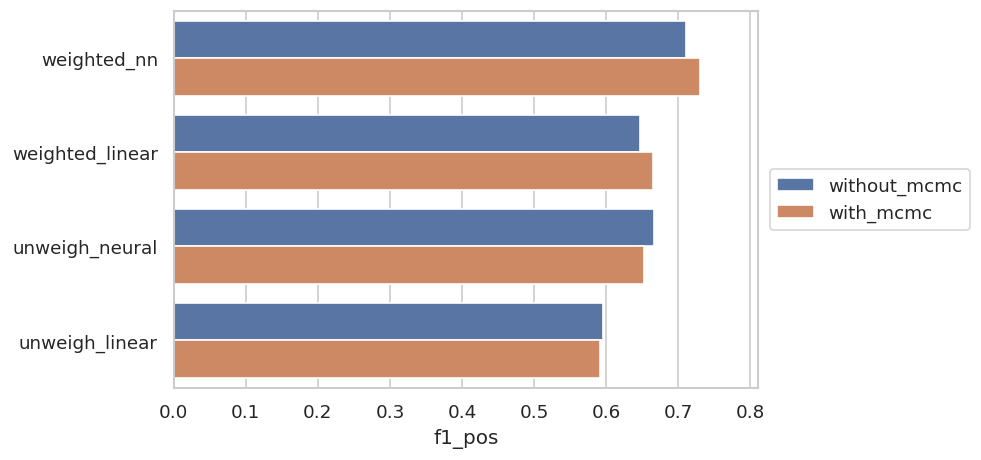

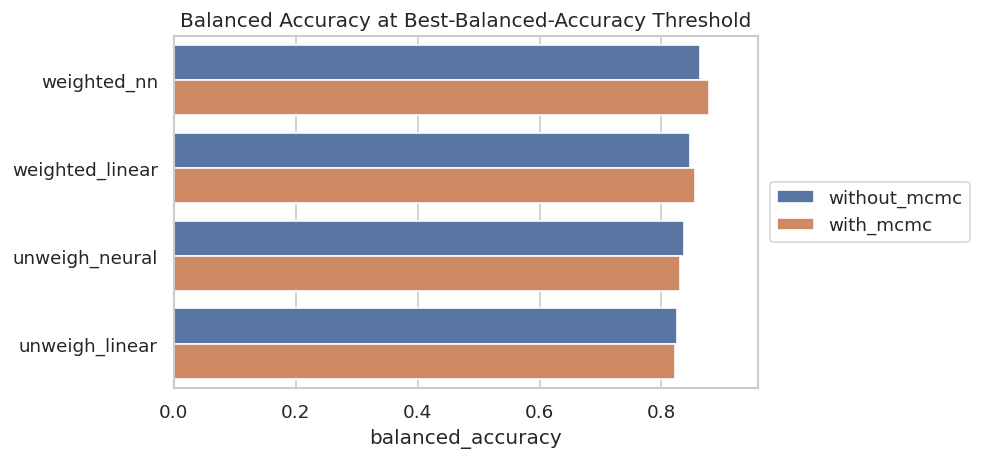

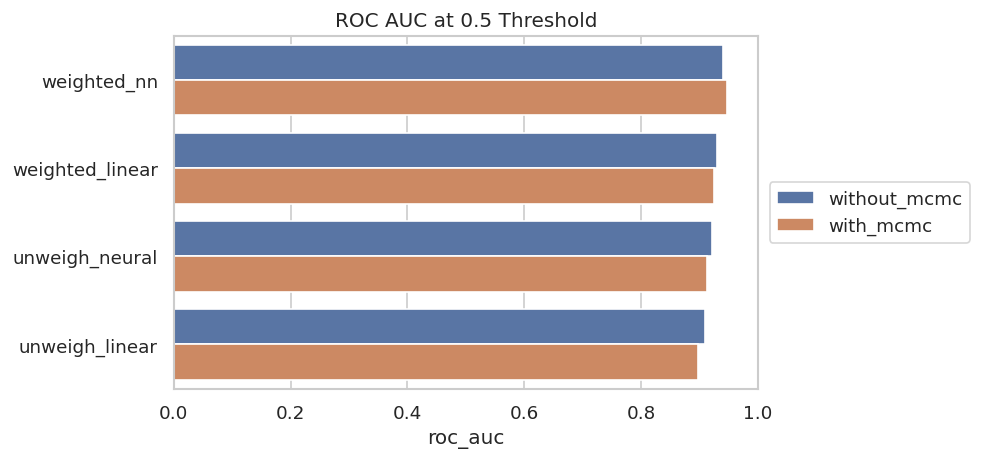

In [44]:
comparison_long = pd.concat([
    without_mcmc.assign(source="without_mcmc"),
    with_mcmc.assign(source="with_mcmc"),
], ignore_index=True)

present_pairs = comparison[["rowname", "threshold_type"]].drop_duplicates()
comparison_long = comparison_long.merge(present_pairs, on=["rowname", "threshold_type"], how="inner")
comparison_long["source"] = pd.Categorical(comparison_long["source"], ["without_mcmc", "with_mcmc"], ordered=True)
comparison_long["threshold_type"] = pd.Categorical(comparison_long["threshold_type"], threshold_order, ordered=True)

bar_specs = [
    ("f1_pos", "best_f1", ""),
    ("balanced_accuracy", "best_balanced_accuracy", "Balanced Accuracy at Best-Balanced-Accuracy Threshold"),
    ("roc_auc", "0.5", "ROC AUC at 0.5 Threshold"),
]

for metric, threshold_type, title in bar_specs:
    chart_df = comparison_long[comparison_long["threshold_type"].eq(threshold_type)].copy()
    row_order = (
        chart_df[chart_df["source"].eq("with_mcmc")]
        .sort_values(metric, ascending=False)["rowname"]
        .tolist()
    )

    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(row_order))))
    sns.barplot(
        data=chart_df,
        y="rowname",
        x=metric,
        hue="source",
        order=row_order,
        hue_order=["without_mcmc", "with_mcmc"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel("")
    ax.set_xlim(0, min(1, max(0.05, chart_df[metric].max() + 0.08)))
    ax.legend(title="", loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
    plt.tight_layout(rect=[0, 0, 0.84, 1])
    plt.show()


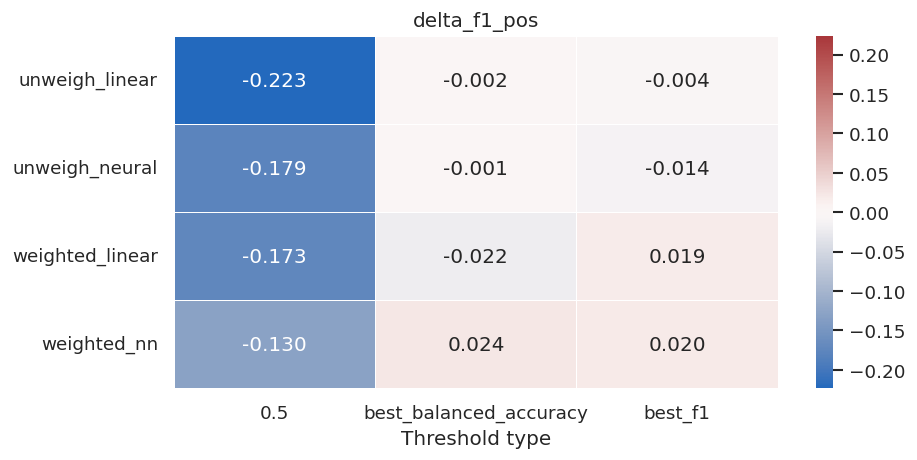

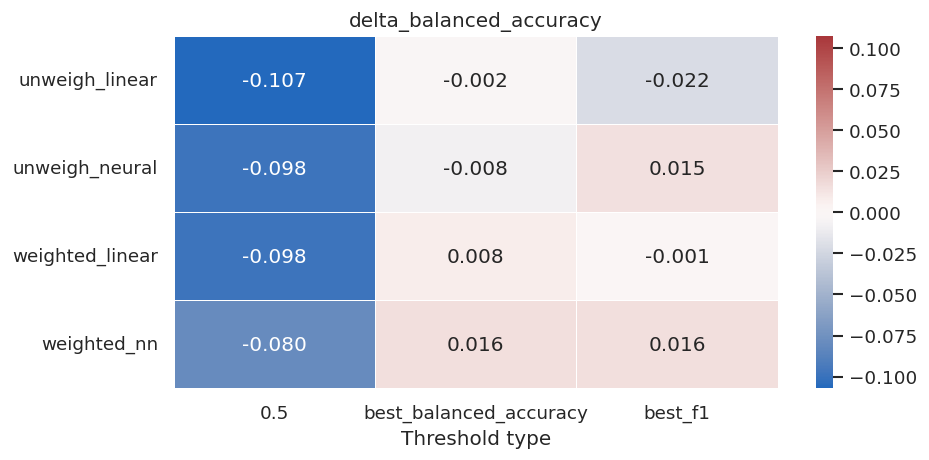

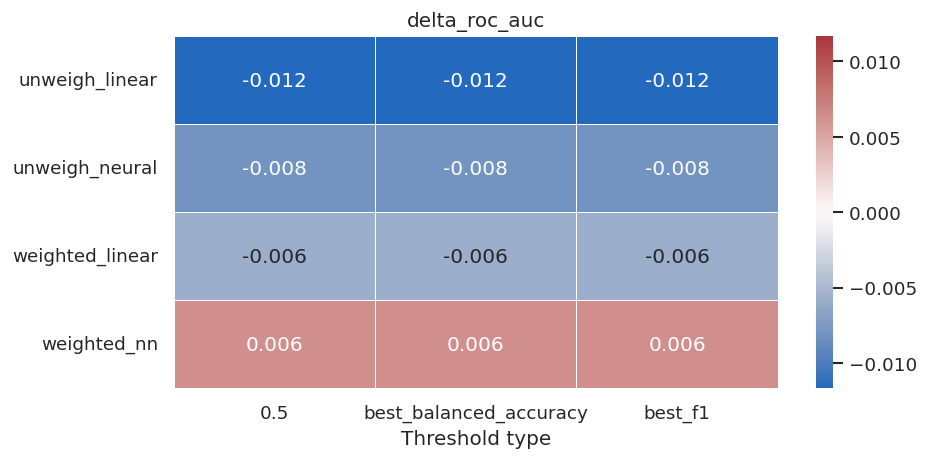

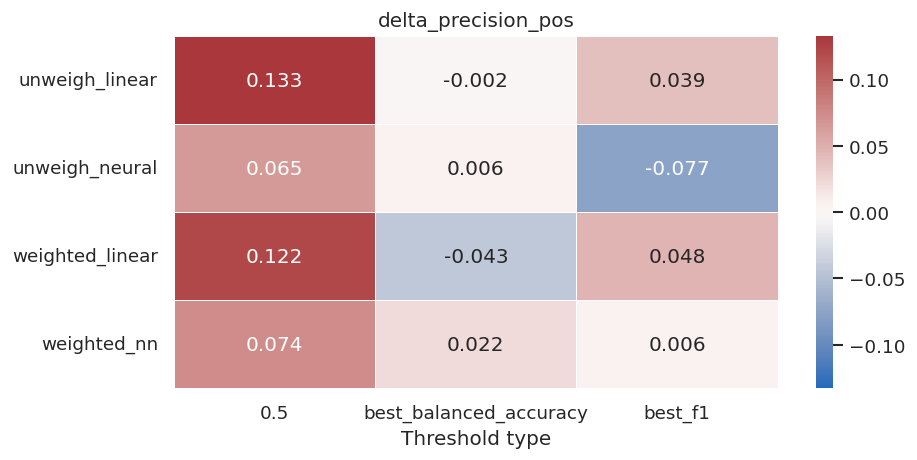

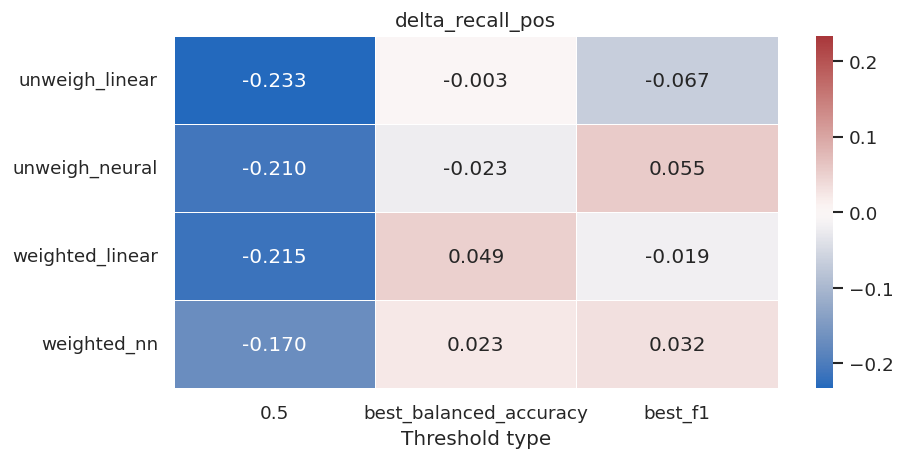

In [45]:
for metric in ["delta_f1_pos", "delta_balanced_accuracy", "delta_roc_auc", "delta_precision_pos", "delta_recall_pos"]:
    heat_df = comparison.pivot(index="rowname", columns="threshold_type", values=metric)
    heat_df = heat_df.reindex(columns=threshold_order)

    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(heat_df))))
    vmax = np.nanmax(np.abs(heat_df.to_numpy()))
    vmax = 0.01 if not np.isfinite(vmax) or vmax == 0 else vmax
    sns.heatmap(
        heat_df,
        annot=True,
        fmt=".3f",
        cmap="vlag",
        center=0,
        vmin=-vmax,
        vmax=vmax,
        linewidths=0.4,
        ax=ax,
    )
    ax.set_title(metric)
    ax.set_xlabel("Threshold type")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


## MCMC Marginal Variance Violin Plots

Load the MCMC posterior files and compare the distributions of `p_i(1-p_i)` side by side for the weighted and unweighted models.

Loaded marginal variances for 4 models from /content/drive/MyDrive/yelp/yelp_mcmc_outputs


/tmp/ipykernel_7203/570729590.py:74: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


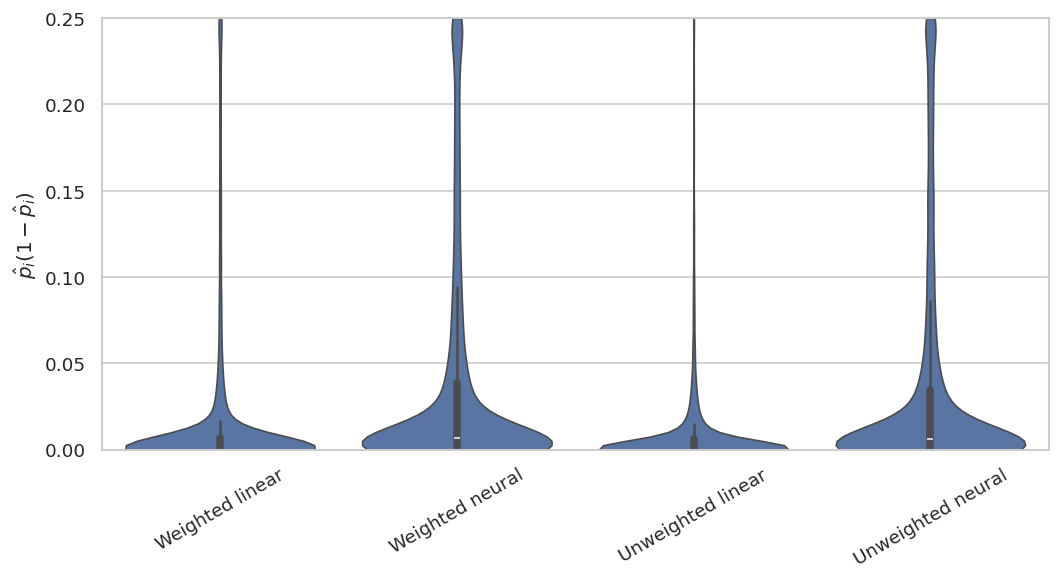

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
Weighted linear,13787.0,0.016710,0.045759,0.0,0.000000,0.000000,0.006951,0.249996
Weighted neural,13787.0,0.037589,0.064343,0.0,0.000999,0.006951,0.038400,0.250000
Unweighted linear,13787.0,0.010195,0.029579,0.0,0.000000,0.000000,0.005964,0.249964
Unweighted neural,13787.0,0.036550,0.064727,0.0,0.000000,0.005964,0.034704,0.250000


In [46]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

MCMC_OUTPUTS_DRIVE_DIR = Path("/content/drive/MyDrive/yelp/yelp_mcmc_outputs")
MCMC_OUTPUTS_LOCAL_DIR = Path("script/yelp/yelp_mcmc_outputs") if Path("script/yelp").exists() else Path("yelp_mcmc_outputs")
MCMC_OUTPUTS_DIR = MCMC_OUTPUTS_DRIVE_DIR if MCMC_OUTPUTS_DRIVE_DIR.exists() else MCMC_OUTPUTS_LOCAL_DIR

MCMC_VARIANCE_MODELS = [
    ("S_hm_weighted_linear", "Weighted linear"),
    ("S_hm_weighted_nn", "Weighted neural"),
    ("S_unweigh_linear", "Unweighted linear"),
    ("S_unweigh_neural", "Unweighted neural"),
]

VAR_NODE_POOL = "all_free"  # one of {"all_free", "all", "fixed"}
variance_frames = []
load_errors = []

for rowname, label in MCMC_VARIANCE_MODELS:
    posterior_path = MCMC_OUTPUTS_DIR / rowname / f"{rowname}_posterior.csv"
    if not posterior_path.exists():
        load_errors.append(f"{label}: missing {posterior_path}")
        continue

    posterior = pd.read_csv(posterior_path)
    if "P_sigma_plus_1" in posterior.columns:
        prob_col = "P_sigma_plus_1"
    elif "P_label_1" in posterior.columns:
        prob_col = "P_label_1"
    elif "p_hat_sigma_plus_1" in posterior.columns:
        prob_col = "p_hat_sigma_plus_1"
    else:
        load_errors.append(f"{label}: no posterior probability column in {posterior_path}")
        continue

    p_hat = pd.to_numeric(posterior[prob_col], errors="coerce")
    marginal_variance = p_hat * (1.0 - p_hat)

    if VAR_NODE_POOL == "all_free" and "fixed_in_mcmc" in posterior.columns:
        pool_mask = ~posterior["fixed_in_mcmc"].astype(bool)
    elif VAR_NODE_POOL == "fixed" and "fixed_in_mcmc" in posterior.columns:
        pool_mask = posterior["fixed_in_mcmc"].astype(bool)
    elif VAR_NODE_POOL in {"all", "all_free"}:
        pool_mask = pd.Series(True, index=posterior.index)
    else:
        raise ValueError("VAR_NODE_POOL must be 'all_free', 'all', or 'fixed'.")

    frame = pd.DataFrame({
        "model": label,
        "rowname": rowname,
        "marginal_variance": marginal_variance,
    })
    frame = frame.loc[pool_mask & frame["marginal_variance"].notna()].copy()
    variance_frames.append(frame)

if load_errors:
    raise FileNotFoundError("Could not load all expected MCMC posterior files:\n" + "\n".join(load_errors))
if not variance_frames:
    raise FileNotFoundError(f"No usable posterior files found under {MCMC_OUTPUTS_DIR}")

variance_df = pd.concat(variance_frames, ignore_index=True)
model_order = [label for rowname, label in MCMC_VARIANCE_MODELS if label in set(variance_df["model"])]

print(f"Loaded marginal variances for {variance_df['model'].nunique()} models from {MCMC_OUTPUTS_DIR}")

fig, ax = plt.subplots(figsize=(max(9, 1.8 * len(model_order)), 5))
sns.violinplot(
    data=variance_df,
    x="model",
    y="marginal_variance",
    order=model_order,
    inner="box",
    cut=0,
    scale="width",
    linewidth=1,
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel(r"$\hat{p}_i(1-\hat{p}_i)$")
ax.set_ylim(0, 0.25)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

variance_df.groupby("model")["marginal_variance"].describe().reindex(model_order)

## Edge-Type Ablation MCMC Variance

Compare the MCMC marginal variance distributions for the weighted neural partial-edge runs. This section searches the MCMC ablation output directory for posterior files whose folder or file name contains each ablation name.

In [47]:
# Same edge-subset ablation design used for the weighted neural ablation notebook.
EDGE_ABLATION_SPECS = {
    "only_net_rur": ["net_rur"],
    "net_rur_plus_net_rsr": ["net_rur", "net_rsr"],
    "net_rur_plus_net_rtr": ["net_rur", "net_rtr"],
}

EDGE_ABLATION_LABELS = {
    "only_net_rur": "net_rur only",
    "net_rur_plus_net_rsr": "net_rur + net_rsr",
    "net_rur_plus_net_rtr": "net_rur + net_rtr",
}

EDGE_ABLATION_ORDER = list(EDGE_ABLATION_SPECS)

# Optional metrics table. The ablation notebook can save ablation_metrics_df here;
# if no CSV is present, the variance plot below still works from posterior files.
ABLATION_METRICS_DRIVE_PATH = Path("/content/drive/MyDrive/yelp/yelp_ablation_metrics.csv")
ABLATION_METRICS_LOCAL_PATH = Path("script/yelp/yelp_ablation_metrics.csv") if Path("script/yelp").exists() else Path("yelp_ablation_metrics.csv")
ABLATION_METRICS_PATH = ABLATION_METRICS_DRIVE_PATH if ABLATION_METRICS_DRIVE_PATH.exists() else ABLATION_METRICS_LOCAL_PATH

if ABLATION_METRICS_PATH.exists():
    edge_ablation_metrics = pd.read_csv(ABLATION_METRICS_PATH)
    print(f"Loaded {len(edge_ablation_metrics):,} edge-ablation metric rows from {ABLATION_METRICS_PATH}")
elif "ablation_metrics_df" in globals():
    edge_ablation_metrics = ablation_metrics_df.copy()
    print("Using in-memory ablation_metrics_df from the current notebook session.")
else:
    edge_ablation_metrics = None
    print(f"No saved edge-ablation metrics found at {ABLATION_METRICS_DRIVE_PATH} or {ABLATION_METRICS_LOCAL_PATH}.")

if edge_ablation_metrics is not None:
    metric_frame = edge_ablation_metrics.rename(columns={
        "threhold_type": "threshold_type",
        "f_1": "f1_pos",
        "f1": "f1_pos",
        "roc-aoc": "roc_auc",
    }).copy()

    if "threshold_strategy" in metric_frame.columns and "threshold_type" not in metric_frame.columns:
        metric_frame["threshold_type"] = metric_frame["threshold_strategy"]

    split_mask = metric_frame["split"].eq("test") if "split" in metric_frame.columns else pd.Series(True, index=metric_frame.index)
    threshold_mask = metric_frame["threshold_type"].isin(["best_f1", "val_f1"])

    test_ablation_metrics = metric_frame[split_mask & threshold_mask].copy()
    if test_ablation_metrics.empty:
        test_ablation_metrics = metric_frame[split_mask].copy()

    for column in ["f1_pos", "balanced_accuracy", "roc_auc", "average_precision", "precision_pos", "recall_pos"]:
        if column in test_ablation_metrics.columns:
            test_ablation_metrics[column] = pd.to_numeric(test_ablation_metrics[column], errors="coerce")

    display_columns = [
        column for column in [
            "ablation", "edge_types_used", "threshold_type", "f1_pos", "balanced_accuracy",
            "roc_auc", "average_precision", "precision_pos", "recall_pos",
        ]
        if column in test_ablation_metrics.columns
    ]
    sort_columns = [column for column in ["f1_pos", "average_precision", "balanced_accuracy"] if column in display_columns]
    table = test_ablation_metrics[display_columns]
    if sort_columns:
        table = table.sort_values(sort_columns, ascending=False)
    display(table)

No saved edge-ablation metrics found at /content/drive/MyDrive/yelp/yelp_ablation_metrics.csv or yelp_ablation_metrics.csv.


Loaded marginal variances for 3 edge ablations from /content/drive/MyDrive/yelp/yelp_mcmc_ablation_outputs


,ablation,edge_types_used
0,only_net_rur,net_rur
13787,net_rur_plus_net_rsr,"net_rur,net_rsr"
27574,net_rur_plus_net_rtr,"net_rur,net_rtr"


/tmp/ipykernel_7203/2595497310.py:112: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


Saved edge-ablation violin plot to figures/fraud_yelp/weighted_nn_marginal_variance_violin_edge_ablation.png


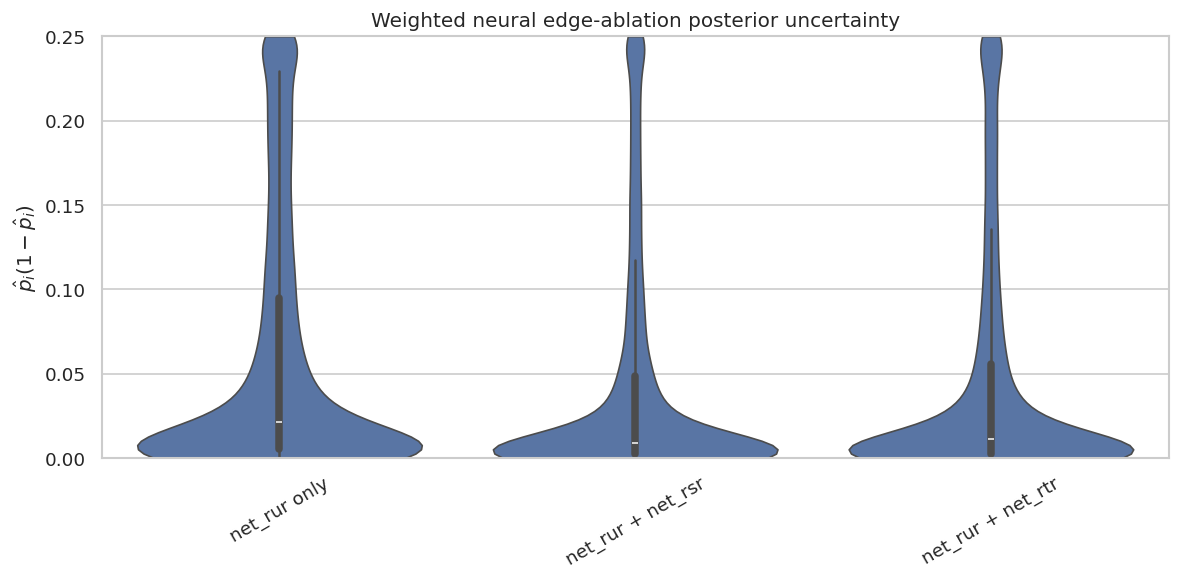

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
net_rur only,13787.0,0.060265,0.075828,0.0,0.004975,0.021516,0.094764,0.25
net_rur + net_rsr,13787.0,0.041851,0.066361,0.0,0.001996,0.008919,0.048399,0.25
net_rur + net_rtr,13787.0,0.045379,0.069172,0.0,0.001996,0.010879,0.055519,0.25


In [48]:
MCMC_ABLATION_OUTPUTS_DRIVE_DIR = Path("/content/drive/MyDrive/yelp/yelp_mcmc_ablation_outputs")
MCMC_ABLATION_OUTPUTS_LOCAL_DIR = (
    Path("script/yelp/yelp_mcmc_ablation_outputs")
    if Path("script/yelp").exists()
    else Path("yelp_mcmc_ablation_outputs")
)
MCMC_ABLATION_OUTPUTS_DIR = (
    MCMC_ABLATION_OUTPUTS_DRIVE_DIR
    if MCMC_ABLATION_OUTPUTS_DRIVE_DIR.exists()
    else MCMC_ABLATION_OUTPUTS_LOCAL_DIR
)


def posterior_probability_column(posterior):
    for column in ["P_sigma_plus_1", "P_label_1", "p_hat_sigma_plus_1"]:
        if column in posterior.columns:
            return column
    raise ValueError("No posterior probability column found; expected P_sigma_plus_1, P_label_1, or p_hat_sigma_plus_1.")


def find_ablation_posterior_path(ablation_name, root_dir):
    root_dir = Path(root_dir)
    candidate_rownames = [
        f"N_hm_weighted_nn_mcmc_ablation_{ablation_name}",
        f"N_hm_weighted_nn_ablation_{ablation_name}",
        f"hm_weighted_nn_ablation_{ablation_name}",
        f"S_hm_weighted_nn_ablation_{ablation_name}",
        ablation_name,
    ]

    search_roots = [
        root_dir / "S_hm_weighted_nn",
        root_dir / "N_hm_weighted_nn_mcmc_ablation",
        root_dir / "N_hm_weighted_nn_ablation",
        root_dir,
    ]

    for search_root in search_roots:
        for rowname in candidate_rownames:
            candidate = search_root / rowname / f"{rowname}_posterior.csv"
            if candidate.exists():
                return candidate
            candidate = search_root / f"{rowname}_posterior.csv"
            if candidate.exists():
                return candidate

    pattern_matches = []
    for search_root in search_roots:
        if search_root.exists():
            pattern_matches.extend(search_root.glob(f"**/*{ablation_name}*_posterior.csv"))

    if pattern_matches:
        return sorted(pattern_matches, key=lambda p: (len(p.parts), str(p)))[0]
    return None


EDGE_ABLATION_VARIANCE_NODE_POOL = "all_free"  # one of {"all_free", "all", "fixed"}
edge_ablation_variance_frames = []
missing_ablation_posteriors = []

for ablation_name, edge_types_used in EDGE_ABLATION_SPECS.items():
    posterior_path = find_ablation_posterior_path(ablation_name, MCMC_ABLATION_OUTPUTS_DIR)
    if posterior_path is None:
        missing_ablation_posteriors.append(ablation_name)
        continue

    posterior = pd.read_csv(posterior_path)
    prob_col = posterior_probability_column(posterior)
    p_hat = pd.to_numeric(posterior[prob_col], errors="coerce")
    marginal_variance = p_hat * (1.0 - p_hat)

    if EDGE_ABLATION_VARIANCE_NODE_POOL == "all_free" and "fixed_in_mcmc" in posterior.columns:
        pool_mask = ~posterior["fixed_in_mcmc"].astype(bool)
    elif EDGE_ABLATION_VARIANCE_NODE_POOL == "fixed" and "fixed_in_mcmc" in posterior.columns:
        pool_mask = posterior["fixed_in_mcmc"].astype(bool)
    elif EDGE_ABLATION_VARIANCE_NODE_POOL in {"all", "all_free"}:
        pool_mask = pd.Series(True, index=posterior.index)
    else:
        raise ValueError("EDGE_ABLATION_VARIANCE_NODE_POOL must be 'all_free', 'all', or 'fixed'.")

    frame = pd.DataFrame({
        "ablation": ablation_name,
        "edge_types_used": ",".join(edge_types_used),
        "model": EDGE_ABLATION_LABELS[ablation_name],
        "posterior_path": str(posterior_path),
        "marginal_variance": marginal_variance,
    })
    edge_ablation_variance_frames.append(frame.loc[pool_mask & frame["marginal_variance"].notna()].copy())

if missing_ablation_posteriors:
    expected = "\n".join(
        f"  - {name}: folder/file name containing '{name}' under {MCMC_ABLATION_OUTPUTS_DIR}"
        for name in missing_ablation_posteriors
    )
    raise FileNotFoundError(
        "Could not find posterior files for these edge ablations. "
        "Run/save the partial-edge MCMC outputs first, then rerun this cell.\n" + expected
    )
if not edge_ablation_variance_frames:
    raise FileNotFoundError(f"No usable edge-ablation posterior files found under {MCMC_ABLATION_OUTPUTS_DIR}")

edge_ablation_variance_df = pd.concat(edge_ablation_variance_frames, ignore_index=True)
edge_ablation_model_order = [EDGE_ABLATION_LABELS[name] for name in EDGE_ABLATION_ORDER]

print(
    f"Loaded marginal variances for {edge_ablation_variance_df['ablation'].nunique()} "
    f"edge ablations from {MCMC_ABLATION_OUTPUTS_DIR}"
)
display(edge_ablation_variance_df[["ablation", "edge_types_used"]].drop_duplicates())

fig, ax = plt.subplots(figsize=(max(10, 1.45 * len(edge_ablation_model_order)), 5))
sns.violinplot(
    data=edge_ablation_variance_df,
    x="model",
    y="marginal_variance",
    order=edge_ablation_model_order,
    inner="box",
    cut=0,
    scale="width",
    linewidth=1,
    ax=ax,
)
ax.set_title("Weighted neural edge-ablation posterior uncertainty")
ax.set_xlabel("")
ax.set_ylabel(r"$\hat{p}_i(1-\hat{p}_i)$")
ax.set_ylim(0, 0.25)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()

FIGURE_OUTPUT_DIR = Path("figures/fraud_yelp")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EDGE_ABLATION_VARIANCE_FIGURE_PATH = FIGURE_OUTPUT_DIR / "weighted_nn_marginal_variance_violin_edge_ablation.png"
fig.savefig(EDGE_ABLATION_VARIANCE_FIGURE_PATH, dpi=300, bbox_inches="tight")
print(f"Saved edge-ablation violin plot to {EDGE_ABLATION_VARIANCE_FIGURE_PATH}")
plt.show()

edge_ablation_variance_df.groupby("model")["marginal_variance"].describe().reindex(edge_ablation_model_order)